### Nonparametric Kernel Smoothing on Penalty

In [33]:
import pandas as pd 
import numpy as np
from scipy.sparse import dia_matrix, csc_matrix
from scipy.sparse.linalg import inv
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.dates import DateFormatter
import sys
from scipy.interpolate import interp1d
from scipy.stats import iqr
import ruptures as rpt
from sklearn.model_selection import train_test_split
import time




path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')
from adaptive_tf_ir import l1tf_adaptive_ir, Dmat

### TAQ Data AAPL

Snippet of AAPL trades on NYSE for 1 hour

In [37]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/cleaned_trades.csv',index_col=0)


trades=trades[trades.index < "2020-01-02 15:59:30"]
trades=trades[trades.index> "2020-01-02 15:59:00"]
trades['Trade_Price']=np.log(trades['Trade_Price'])
trades.index=pd.to_datetime(trades.index)
trades

,SIP_Timestamp,Exchange,Symbol,Trade_Volume,Trade_Price,Sale_Condition,Source_of_Trade,Trade_Correction_Indicator,Sequence_Number,Trade_Id,Trade_Reporting_Facility,Trade_Through_Exempt_Indicator,date
2020-01-02 15:59:00.001618,2020-01-02 15:59:00.001638,Q,AAPL,100,5.705115,@F,N,0,3048096,66973,,1,2020-01-02
2020-01-02 15:59:00.005779,2020-01-02 15:59:00.005800,Q,AAPL,200,5.705115,@,N,0,3048100,66974,,0,2020-01-02
2020-01-02 15:59:00.013466,2020-01-02 15:59:00.013843,P,AAPL,100,5.705115,@F,N,0,3048117,27428,,1,2020-01-02
2020-01-02 15:59:00.017512,2020-01-02 15:59:00.017737,K,AAPL,99,5.705115,@ I,N,0,3048127,18316,,0,2020-01-02
2020-01-02 15:59:00.017641,2020-01-02 15:59:00.018016,P,AAPL,1,5.705115,@ I,N,0,3048130,27429,,0,2020-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-02 15:59:29.865972,2020-01-02 15:59:29.866183,K,AAPL,100,5.705181,@F,N,0,3073605,18411,,1,2020-01-02
2020-01-02 15:59:29.866298,2020-01-02 15:59:29.866316,Q,AAPL,200,5.705215,@F,N,0,3073606,67525,,1,2020-01-02
2020-01-02 15:59:29.866298,2020-01-02 15:59:29.866320,Q,AAPL,99,5.705215,@F I,N,0,3073607,67526,,1,2020-01-02
2020-01-02 15:59:29.896744,2020-01-02 15:59:29.896763,Q,AAPL,35,5.705148,@F I,N,0,3073623,67527,,1,2020-01-02


Text(0.5, 1.0, 'APPL Trade Price 01/15/2020')

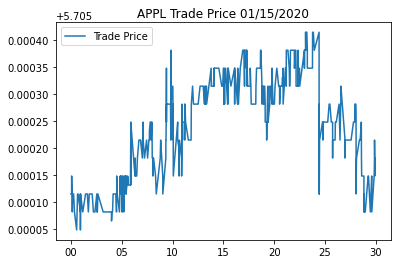

In [38]:
fig,ax=plt.subplots()
ax.plot(trades['Trade_Price'],label='Trade Price')
ax.legend()
ax.xaxis.set_major_formatter(DateFormatter('%S'))
ax.set_title("APPL Trade Price 01/15/2020")

In [39]:
vol=trades['Trade_Volume']

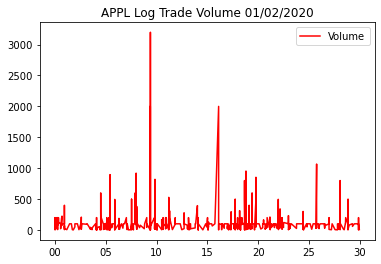

In [40]:
fig,ax=plt.subplots()
ax.set_title("APPL Log Trade Volume 01/02/2020")
ax.xaxis.set_major_formatter(DateFormatter('%S'))
ax.plot(vol,color='red',label='Volume')
ax.legend()

### Compute Max Lambda 

As denoted in L1 Trend Filtering, smallest maximum for which $\forall \lambda \geq \lambda_{max}$ the L1 trend filtering returns the best linear affine fit
$$\lambda_{max}=||(DD^T)^{-1}Dy||_\infty$$

For adaptiveness; one idea to show that the max of each component corresponds to the max of that single partition is that the trivial example of the best affine fit between two points simplify to linear interpolation

In [41]:
def max_norm(y,k=2,adaptive=False,verbose=True):
    """ Computes smallest max norm via scipy sparse matrices for efficiency
    """
    D=Dmat(len(y),k)
    
    D=D.tocsc()
   
    D_DT=inv(D@D.T)
    
    
    if adaptive is False:
        max_lam=abs(D_DT@D@y).max()
    else:
        max_lam=abs(D_DT@D@y)
        
    if verbose:
        print("Condition Number is ",np.linalg.cond((D@D.T).toarray()))
    return max_lam

In [42]:
lambda_val=max_norm(trades['Trade_Price'].values,k=2)
lambda_val

Condition Number is  42845647317.21987


5.643879641426906

Condition Number is  42845647317.21987


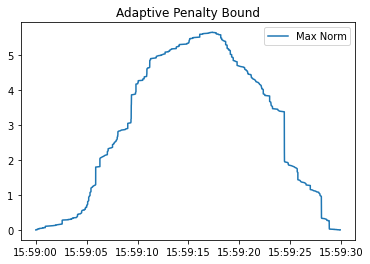

In [43]:
lambda_val=max_norm(trades['Trade_Price'].values,2,True)
plt.title("Adaptive Penalty Bound")

plt.plot(trades['Trade_Price'].index[1:-1],lambda_val,label='Max Norm')
plt.legend()

### Apply Kernel Smoothing on Volume Time Series

Applies Kernel Spatial Smoothing s.t. 

$$\hat{Y}(x_j)=\frac{\sum_{t=1}^T K_\sigma(x_i,x_j)Y(x_i)}{\sum_{t=1}^T K_\sigma(x_i,x_j)}$$ 

Where our kernel function is the Gaussian Kernel

Or we can default to silvermans/scotts (however these have parametric assumptions)

In [44]:
def compute_kernel(x_0,x_i,bandwidth):
    '''
    Given two points x_0 and x_i; compute the gaussian kernel utilizing euclidean distance 
    '''
    scale=abs((x_0-x_i)/bandwidth) # absolute distance in time
    
    weight= np.exp(-scale**2)
      
    return weight

def kernel_smooth(x0,series,pen,bw):
    '''
    x0: index of recent observation
    series: observations
    pen: max lambda to scale kernel to
    
    Note we use the asymptotically optimal bandwidth param for the Epan. Kernel


    '''
    num=0
    ker=0
    
    counter=0
    for index,val in series.items():
        
        kernel=compute_kernel(x0,index,bw) # compute weight as a function of time 
        ker+=kernel
     
        num+=kernel*val*pen[counter] # kernel smoothed series constrained by penalty 

        counter+=1

    return (num/ker)

In [47]:
def smooth_series(k_series,p_series,t=None):
    
    '''
     
    Kernel Smooths a series using the gaussian kerenl
    
    i). Applies Min-Max Normalization to scale -> [0,1]
    ii). Applies Kernel Smoothing with penalty scaling-> [0,1]
    iii). Utilizes Scotts and Silvermans Bandwidth Selection Methods 
        

        
    '''
    
    smooth=[]
    
    pen=np.pad(max_norm(y=p_series.values,k=2,adaptive=True,verbose=False),(1,1))
    
    k_seconds=(k_series.index-k_series.index[0]).total_seconds() 
    normalized_data=(k_series.values-np.min(k_series.values))/(np.max(k_series.values)-np.min(k_series.values))
    
    normalized_series=pd.Series(normalized_data,index=k_seconds)
    
    silver_bw=0.9*min(np.std(k_series),iqr(k_series)/1.35)/(len(k_series)**0.2)
    scott_bw=1.06*np.std(k_series) / (len(k_series)**0.2)
    for x_i_index, x_i in normalized_series.items():
        smoothed_val=kernel_smooth(x_i_index,normalized_series,pen,scott_bw)
        smooth.append(smoothed_val)
   
    smooth=pd.Series(smooth,index=k_series.index)
    
        
    return smooth,pen

In [48]:
smooth,pen=smooth_series(trades['Trade_Volume'],trades['Trade_Price'])

In [49]:
scott_bw=1.06*np.std(trades['Trade_Volume']) / (len(trades['Trade_Volume'])**0.2)
print("Optimal BW is", scott_bw)

Optimal BW is 51.39551151343437


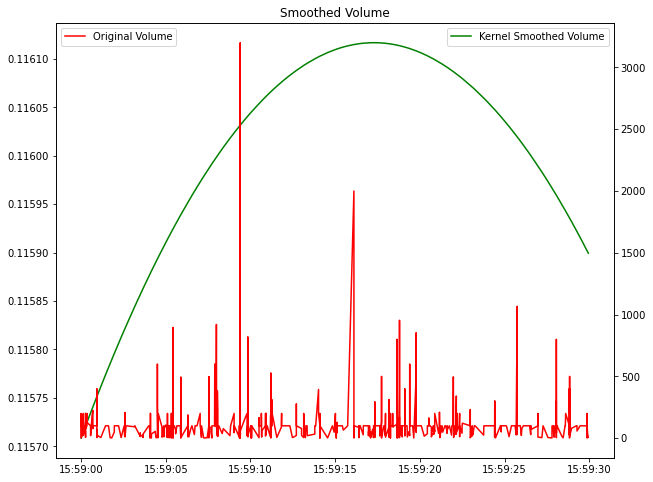

In [50]:
fig,ax=plt.subplots(figsize=(10,8))
ax.plot(smooth.index,smooth.values,label='Kernel Smoothed Volume',color='green')

ax.set_title("Smoothed Volume")
ax2=ax.twinx()
ax2.plot(vol,color='red',label='Original Volume')
ax.legend()
ax2.legend(loc='upper left')

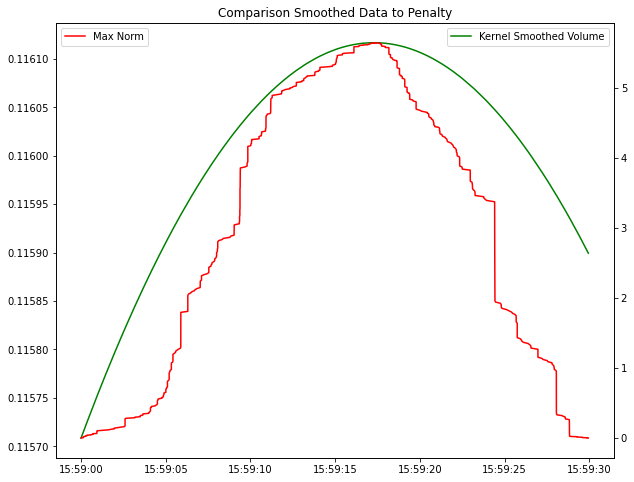

In [51]:
fig,ax=plt.subplots(figsize=(10,8))
ax.plot(smooth.index,smooth.values,label='Kernel Smoothed Volume',color='green')

ax.set_title("Comparison Smoothed Data to Penalty")
ax2=ax.twinx()
ax2.plot(smooth.index,pen,color='red',label='Max Norm')
ax.legend()
ax2.legend(loc='upper left')